Inizializzazione

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import h5py
from torch.utils.data import Dataset, DataLoader
import os # Importato per gestire il salvataggio dei file

#stato = raggi raytracing: 256, velocità lineare: 3, velocità angolare: 3, orientamento: 4 utilizzo dei quaternioni per efficienza
input_dim = 536 #(266 stato attuale + 4 motori + 266 stato successivo)

# 1. DEEN
class DEEN_Network(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),           # Ottimizzazione 1: Stabilizza i gradienti
            nn.SiLU(),                   # Ottimizzazione 2: Attivazione fluida (Swish)
            nn.Dropout(dropout_rate),    # Ottimizzazione 3: Previene l'overfitting sui raytracing

            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.SiLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.SiLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),       #aggiunto nuovo layer per non passare direttamente da 512 a 128
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(dropout_rate),


            nn.Linear(128, 1)            # Output: Singolo scalare (Energia)
        )

    def forward(self, x):
        return self.net(x)

# 2. LOSS FUNCTION
def deen_loss_function(ebm_model, x_clean, sigma=0.1):
    # Aggiungo rumore
    noise = torch.randn_like(x_clean) * sigma

    y_corrupted = (x_clean + noise).detach().requires_grad_(True)

    # Calcolo Energia
    energy = ebm_model(y_corrupted)

    # Calcolo Gradienti (Score Function)
    score_function = torch.autograd.grad(
        outputs=energy.sum(),
        inputs=y_corrupted,
        create_graph=True, # FONDAMENTALE per la backpropagation successiva
        retain_graph=True
    )[0]

    # E. Loss Function del paper (Denoising Score Matching)
    error = x_clean - y_corrupted + (sigma**2) * score_function
    loss = torch.mean(error**2)

    return loss

# 3. SETUP DI ADDESTRAMENTO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DEEN_Network(input_dim, dropout_rate=0.2).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

Caricamento Dataset

In [6]:
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

# =========================================================================
# 1. CLASSE DATASET SEMPLIFICATA
# =========================================================================
class DroneVoxelDataset(Dataset):
    def __init__(self, data_array, nome_set):
        self.data = torch.tensor(data_array, dtype=torch.float32)
        print(f" ✔️ {nome_set} Set pronto! Totale campioni: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# =========================================================================
# 2. CARICAMENTO, FIX INDICI E TAGLIO DEL FILE HDF5
# =========================================================================
# Percorso del file su Google Drive
file_dataset = '/content/drive/MyDrive/Colab Notebooks/dataset_deen_ottimizzato.h5'

print(f"Apertura del dataset globale da {file_dataset}...")

# Apriamo in modalità 'a' (append) nel caso serva sistemare gli indici
with h5py.File(file_dataset, 'a') as f:

    # Controllo di sicurezza per gli indici
    if 'split_indices' not in f:
        print("⚠️ Indici non trovati! Li aggiungo adesso in modo permanente...")
        indici_corretti = np.array([[842695, 959193]])
        f.create_dataset('split_indices', data=indici_corretti)
        print("✅ Indici salvati con successo!")

    print("Caricamento transizioni in memoria...")
    dataset_completo = f['transitions'][:]

    # Leggiamo gli indici esatti
    indici = f['split_indices'][:]
    idx_train = int(indici[0][0])
    idx_val   = int(indici[0][1])

print("Taglio dei dataset in corso...")
# Slicing matematico perfetto: nessun dato si mescolerà tra i set!
X_train = dataset_completo[0 : idx_train, :]
X_val   = dataset_completo[idx_train : idx_val, :]
X_test  = dataset_completo[idx_val : , :]

# --- NORMALIZZAZIONE Z-SCORE ---
print("Normalizzazione Z-Score dei dati in corso...")
# Calcoliamo Media e Dev. Standard SOLO sul Train per evitare Data Leakage!
mean_train = np.mean(X_train, axis=0)
std_train  = np.std(X_train, axis=0) + 1e-8 # 1e-8 evita divisioni per zero

# Applichiamo la stessa scala a tutti e tre i set
X_train = (X_train - mean_train) / std_train
X_val   = (X_val - mean_train) / std_train
X_test  = (X_test - mean_train) / std_train

# Liberiamo la memoria della variabile globale che non ci serve più per risparmiare RAM
del dataset_completo

# =========================================================================
# 3. PREPARAZIONE DATALOADERS PER PYTORCH
# =========================================================================
print("\n--- PREPARAZIONE TRAIN SET ---")
train_dataset = DroneVoxelDataset(X_train, "Training")
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print("\n--- PREPARAZIONE VALIDATION SET ---")
val_dataset = DroneVoxelDataset(X_val, "Validation")
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print("\n--- PREPARAZIONE TEST SET ---")
test_dataset = DroneVoxelDataset(X_test, "Testing")
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

Apertura del dataset globale da /content/drive/MyDrive/Colab Notebooks/dataset_deen_ottimizzato.h5...
Caricamento transizioni in memoria...
Taglio dei dataset in corso...
Normalizzazione Z-Score dei dati in corso...

--- PREPARAZIONE TRAIN SET ---
 ✔️ Training Set pronto! Totale campioni: 842695

--- PREPARAZIONE VALIDATION SET ---
 ✔️ Validation Set pronto! Totale campioni: 116498

--- PREPARAZIONE TEST SET ---
 ✔️ Testing Set pronto! Totale campioni: 103892


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Addestramento

Epoca 001/100 | Train Loss: 0.00699 | Val Loss: 0.00493 💾 (Miglioramento Val! Modello salvato)
Epoca 002/100 | Train Loss: 0.00358 | Val Loss: 0.00192 💾 (Miglioramento Val! Modello salvato)
Epoca 003/100 | Train Loss: 0.00200 | Val Loss: 0.00184 💾 (Miglioramento Val! Modello salvato)
Epoca 004/100 | Train Loss: 0.00185 | Val Loss: 0.00182 💾 (Miglioramento Val! Modello salvato)
Epoca 005/100 | Train Loss: 0.00182 | Val Loss: 0.00181 💾 (Miglioramento Val! Modello salvato)
Epoca 006/100 | Train Loss: 0.00179 | Val Loss: 0.00179 💾 (Miglioramento Val! Modello salvato)
Epoca 007/100 | Train Loss: 0.00177 | Val Loss: 0.00179 💾 (Miglioramento Val! Modello salvato)
Epoca 008/100 | Train Loss: 0.00176 | Val Loss: 0.00177 💾 (Miglioramento Val! Modello salvato)
Epoca 009/100 | Train Loss: 0.00173 | Val Loss: 0.00175 💾 (Miglioramento Val! Modello salvato)
Epoca 010/100 | Train Loss: 0.00171 | Val Loss: 0.00174 💾 (Miglioramento Val! Modello salvato)
Epoca 011/100 | Train Loss: 0.00168 | Val Loss: 0.

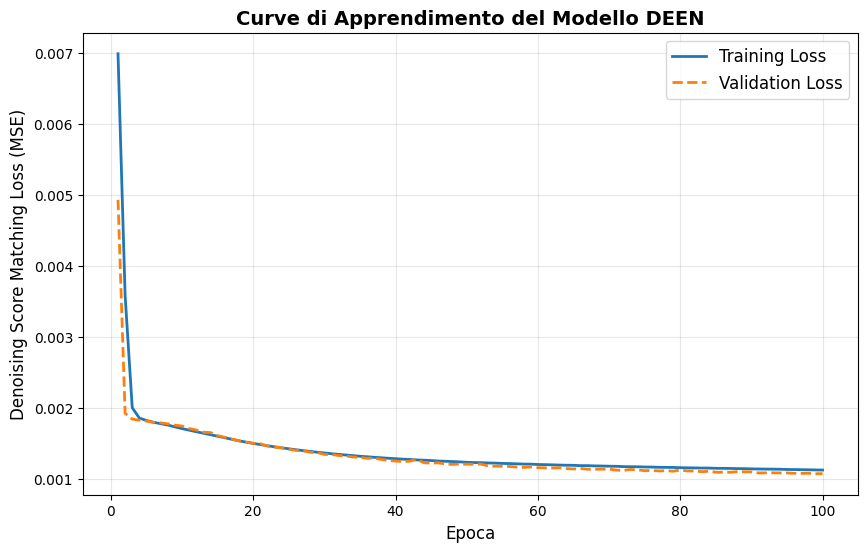

📸 Grafico delle curve di apprendimento salvato come 'learning_curves.png'


In [7]:
import matplotlib.pyplot as plt

def train_deen(model, train_loader, val_loader, num_epochs=100, sigma=0.1, save_path="best_deen_model.pth"):
    best_val_loss = float('inf')

    # NUOVO: Liste per salvare lo storico delle loss per il grafico
    history_train_loss = []
    history_val_loss = []

    for epoch in range(num_epochs):
        # --- FASE 1: TRAINING ---
        model.train()
        train_loss = 0.0

        for batch_x_clean in train_loader:
            batch_x_clean = batch_x_clean.to(device)
            optimizer.zero_grad()

            loss = deen_loss_function(model, batch_x_clean, sigma)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- FASE 2: VALIDATION ---
        model.eval()
        val_loss = 0.0

        for batch_val_clean in val_loader:
            batch_val_clean = batch_val_clean.to(device)
            v_loss = deen_loss_function(model, batch_val_clean, sigma)
            val_loss += v_loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # NUOVO: Salvataggio dei valori nelle liste
        history_train_loss.append(avg_train_loss)
        history_val_loss.append(avg_val_loss)

        # --- FASE 3: SALVATAGGIO ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            salvato_msg = f" 💾 (Miglioramento Val! Modello salvato)"
        else:
            salvato_msg = ""

        print(f"Epoca {epoch+1:03d}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}{salvato_msg}")
        scheduler.step(avg_val_loss)

    print(f"\n✅ Addestramento completato. Miglior Val Loss: {best_val_loss:.6f}")
    model.load_state_dict(torch.load(save_path))
    print("Modello migliore ricaricato e pronto per l'esportazione!")

    # NUOVO: Restituiamo anche le due liste per poterle plottare!
    return model, history_train_loss, history_val_loss

# --- Avvio dell'addestramento ---
model, train_history, val_history = train_deen(
    model, train_loader, val_loader, num_epochs=100, sigma=0.1, save_path="best_deen_weights.pth"
)

# --- GENERAZIONE GRAFICO LEARNING CURVES ---
plt.figure(figsize=(10, 6))

# Creiamo l'asse X (il numero delle epoche da 1 a 100)
epoche = range(1, len(train_history) + 1)

# Plottiamo le due linee
plt.plot(epoche, train_history, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(epoche, val_history, label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='dashed')

# Formattazione per renderlo perfetto per la tesi
plt.title('Curve di Apprendimento del Modello DEEN', fontsize=14, fontweight='bold')
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Denoising Score Matching Loss (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Limitiamo l'asse Y per evitare che i primissimi valori altissimi schiaccino il grafico (opzionale)
# Se il grafico risulta troppo piatto all'inizio, puoi scommentare la riga sotto:
# plt.ylim([0.004, 0.010])

# Salviamo l'immagine
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("📸 Grafico delle curve di apprendimento salvato come 'learning_curves.png'")

Testing

🔍 Inizio test di generalizzazione (Zero-Shot) sulla Città 10...

✅ Test Completato!
🔋 Energia Media Sicura (Reale): -1100.0149
⚠️ Energia Media Pericolosa (Rumore): -829.2444
📈 Distanza (Separazione): 270.7705

🎉 SUCCESSO! Il modello ha creato un 'pozzo di energia' attorno alle traiettorie sicure.


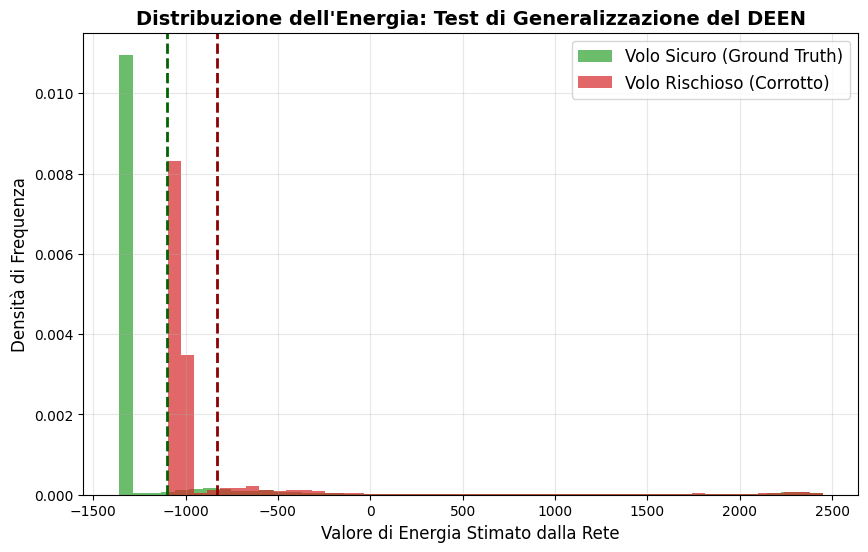

📸 Grafico salvato come 'deen_energy_distribution.png' (Pronto per la tesi!)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================================
# FUNZIONE DI TESTING DELL'ENERGIA E PLOTTING
# =========================================================================
def test_deen_energy(model, test_dataloader, sigma=0.1):
    model.eval() # FONDAMENTALE: spegne il Dropout per il test

    energie_pulite = []
    energie_corrotte = []

    print("🔍 Inizio test di generalizzazione (Zero-Shot) sulla Città 10...")

    with torch.no_grad(): # Niente gradienti: velocissimo e non consuma RAM
        for batch_x_clean in test_dataloader:
            batch_x_clean = batch_x_clean.to(device)

            # 1. Energia Traiettorie Sicure (Il volo calcolato da MATLAB)
            energy_clean = model(batch_x_clean)
            energie_pulite.extend(energy_clean.cpu().numpy().flatten())

            # 2. Energia Traiettorie Pericolose (Aggiungiamo rumore critico)
            noise = torch.randn_like(batch_x_clean) * sigma
            batch_x_corrupted = batch_x_clean + noise

            energy_corrupted = model(batch_x_corrupted)
            energie_corrotte.extend(energy_corrupted.cpu().numpy().flatten())

    # --- Calcolo Statistiche ---
    media_pulita = np.mean(energie_pulite)
    media_corrotta = np.mean(energie_corrotte)
    delta = media_corrotta - media_pulita

    print(f"\n✅ Test Completato!")
    print(f"🔋 Energia Media Sicura (Reale): {media_pulita:.4f}")
    print(f"⚠️ Energia Media Pericolosa (Rumore): {media_corrotta:.4f}")
    print(f"📈 Distanza (Separazione): {delta:.4f}")

    if delta > 0:
        print("\n🎉 SUCCESSO! Il modello ha creato un 'pozzo di energia' attorno alle traiettorie sicure.")
    else:
        print("\n❌ ATTENZIONE! Il modello fa fatica a distinguere il pericolo.")

    # --- GENERAZIONE GRAFICO PER LA TESI ---
    plt.figure(figsize=(10, 6))

    # Istogramma Verde (Sicuro)
    plt.hist(energie_pulite, bins=50, alpha=0.7, color='#2ca02c', label='Volo Sicuro (Ground Truth)', density=True)
    # Istogramma Rosso (Pericolo)
    plt.hist(energie_corrotte, bins=50, alpha=0.7, color='#d62728', label='Volo Rischioso (Corrotto)', density=True)

    # Linee delle medie
    plt.axvline(media_pulita, color='darkgreen', linestyle='dashed', linewidth=2)
    plt.axvline(media_corrotta, color='darkred', linestyle='dashed', linewidth=2)

    plt.title('Distribuzione dell\'Energia: Test di Generalizzazione del DEEN', fontsize=14, fontweight='bold')
    plt.xlabel('Valore di Energia Stimato dalla Rete', fontsize=12)
    plt.ylabel('Densità di Frequenza', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)

    # Salva l'immagine ad alta risoluzione
    plt.savefig('deen_energy_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("📸 Grafico salvato come 'deen_energy_distribution.png' (Pronto per la tesi!)")

    return energie_pulite, energie_corrotte

# =========================================================================
# ESECUZIONE DEL TEST
# =========================================================================
# Passiamo il test_loader generato in precedenza
clean_e, corrupted_e = test_deen_energy(model, test_loader, sigma=0.1)

Esportazione

In [9]:
!pip install onnx onnxscript

def esporta_in_onnx(model, nome_file="deen_addestrato.onnx"):
    model.eval()

    dummy_input = torch.randn(1, input_dim, requires_grad=True).to(device)

    print(f"Esportazione del modello in {nome_file}...")

    torch.onnx.export(
        model,
        dummy_input,
        nome_file,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input_transition'],
        output_names=['energy_score']
    )
    print("Esportazione completata con successo! Ora puoi importarlo in MATLAB.")

esporta_in_onnx(model, "deen_addestrato_v2.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 12.1 MB/s eta 0:00:00
Esportazione del modello in deen_addestrato_v2.onnx...


W0501 16:00:33.108000 1957 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DEEN_Network([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DEEN_Network([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Esportazione completata con successo! Ora puoi importarlo in MATLAB.
